原始影像 shape: (512, 512, 3)
預處理後 shape: (512, 512, 3)
預處理後 最小值: 0.0, 最大值: 1.0
預處理後 Dtype: float32


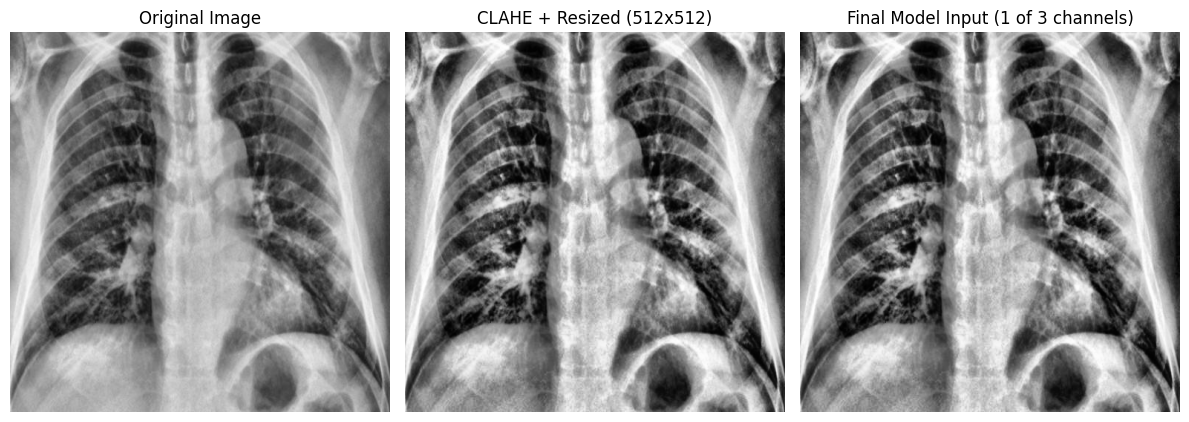

In [11]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def load_image_grayscale(image_path):
    """
    以灰階模式讀取影像。
    CXR 影像是單色的，但儲存時可能是 1 通道 (Grayscale) 或 3 通道 (BGR)。
    我們統一以灰階讀取來標準化。
    """
    # cv2.IMREAD_GRAYSCALE 確保我們總是得到 1 通道的影像
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"警告: 無法讀取影像 {image_path}")
        return None
    return img

def apply_clahe(img):
    """
    應用 CLAHE (對比度限制自適應直方圖均衡化)
    這有助於增強肺部 X 光片中可能模糊的細節 (如毛玻璃狀)。
    """
    # clipLimit: 對比度限制，值越高對比度越強
    # tileGridSize: 將影像分成的小區塊，(8, 8) 是常用預設值
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6, 6))
    enhanced_img = clahe.apply(img)
    return enhanced_img

def resize_image(img, target_size=(224, 224)):
    """
    將影像重塑為模型所需的固定尺寸。
    """
    # cv2.INTER_AREA 適用於縮小影像，保留更多特徵
    # cv2.INTER_CUBIC 或 cv2.INTER_LANCZOS4 適用於放大
    if img.shape[0] > target_size[0] or img.shape[1] > target_size[1]:
        interpolation = cv2.INTER_AREA
    else:
        interpolation = cv2.INTER_CUBIC
        
    resized_img = cv2.resize(img, target_size, interpolation=interpolation)
    return resized_img

def normalize_and_prepare_model_input(img, target_size=(224, 224)):
    """
    正規化影像並處理通道數以符合預訓練模型 (如 ResNet, VGG)。
    
    原始 `img` 應為 1 通道、[0, 255] 範圍的 uint8 影像 (H, W)。
    """
    
    # 步驟 1: 處理通道 (Channel Handling)
    # 將 1 通道灰階 (H, W) 轉換為 3 通道 (H, W, 3)
    # `cv2.COLOR_GRAY2BGR` 會自動將單一通道複製三次
    if len(img.shape) != 2:
        print(f"警告: 輸入的影像不是 1 通道 (H, W)，shape 為 {img.shape}")
        # 嘗試取第一個通道 (如果它是 (H, W, 1))
        if len(img.shape) == 3 and img.shape[2] == 1:
            img = img[:, :, 0]
        else:
            print("錯誤: 無法處理的影像通道格式。")
            return None
            
    img_3_channel = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    # 步驟 2: 標準化 (Normalization)
    # 將型別從 uint8 轉換為 float32 並將範圍從 [0, 255] 縮放到 [0, 1]
    # (使用 np.float32)
    final_img = img_3_channel.astype(np.float32) / 255.0
    
    # (可選) 許多模型 (如 PyTorch) 偏好 (C, H, W) 格式
    # final_img = np.transpose(final_img, (2, 0, 1))
    
    return final_img

def preprocess_pipeline(image_path, target_size=(512, 512)):
    """
    整合所有預處理步驟的完整流程。
    """
    # 1. 讀取灰階影像
    img = load_image_grayscale(image_path)
    if img is None:
        return None
    
    # 2. 應用 CLAHE 增強對比度
    img_enhanced = apply_clahe(img)
    
    # 3. 重塑為目標大小
    img_resized = resize_image(img_enhanced, target_size)
    
    # 4. 標準化並準備模型輸入 (處理通道)
    final_model_input = normalize_and_prepare_model_input(img_resized, target_size)
    
    return final_model_input

# --- 主程式：執行與可視化 ---
if __name__ == "__main__":
    # 替換為您自己的範例 X 光影像路徑
    # (您需要先準備一張影像才能執行)
    # image_path = "path/to/your/chest_xray.jpg"
    image_path = "../segmented_datasets_v2/train_images/19.jpeg" # <--- 請替換這裡

    if not os.path.exists(image_path):
        print(f"錯誤: 找不到範例影像 '{image_path}'")
        print("請下載一張X光影像並將路徑替換 'YOUR_IMAGE_PATH.jpg'")
    else:
        TARGET_IMG_SIZE = (512, 512)

        # 載入原始影像
        original_img = cv2.imread(image_path)
        
        # 執行完整的預處理流程
        processed_img = preprocess_pipeline(image_path, target_size=TARGET_IMG_SIZE)
        
        if processed_img is not None:
            print(f"原始影像 shape: {original_img.shape}")
            print(f"預處理後 shape: {processed_img.shape}")
            print(f"預處理後 最小值: {processed_img.min()}, 最大值: {processed_img.max()}")
            print(f"預處理後 Dtype: {processed_img.dtype}")
            
            # 可視化結果
            # 我們需要將 [0, 1] 範圍的 3 通道影像轉回 [0, 255] 的 uint8 才能正確顯示
            
            # 為了比較，我們也單獨執行 CLAHE 和 resize
            img_gray = load_image_grayscale(image_path)
            img_clahe = apply_clahe(img_gray)
            img_clahe_resized = resize_image(img_clahe, TARGET_IMG_SIZE)
            
            plt.figure(figsize=(12, 6))
            
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
            plt.title("Original Image")
            plt.axis("off")
            
            plt.subplot(1, 3, 2)
            # 顯示應用 CLAHE 並 resize 後的影像 (單通道)
            plt.imshow(img_clahe_resized, cmap='gray')
            plt.title(f"CLAHE + Resized ({TARGET_IMG_SIZE[0]}x{TARGET_IMG_SIZE[1]})")
            plt.axis("off")
            
            plt.subplot(1, 3, 3)
            # 顯示最終輸入模型的影像 (取第一個通道，因為三者相同)
            # 由於 processed_img 範圍是 [0, 1]，imshow 會自動處理
            plt.imshow(processed_img[:, :, 0], cmap='gray')
            plt.title(f"Final Model Input (1 of 3 channels)")
            plt.axis("off")
            
            plt.tight_layout()
            plt.show()

In [12]:
root_dir = "../segmented_datasets_v2/"
dataset_dirs = ["val_images", "train_images", "test_images"]
preprocessed_output_dir = "../preprocessed_datasets_v2/"

# 確保基礎的輸出目錄存在
os.makedirs(preprocessed_output_dir, exist_ok=True)
print(f"基礎輸出目錄: {preprocessed_output_dir}")

TARGET_IMG_SIZE = (512, 512) # 您將尺寸改為 512x512

for dataset_dir in dataset_dirs:
    # 建立對應的子目錄 (例如 ../preprocessed_datasets/train_images)
    output_subdir = os.path.join(preprocessed_output_dir, dataset_dir)
    os.makedirs(output_subdir, exist_ok=True)
    print(f"\n正在處理目錄: {dataset_dir}，儲存至: {output_subdir}")
    
    input_dir_path = os.path.join(root_dir, dataset_dir)
    
    # 修正 #1: 迴圈遍歷檔案
    for filename in os.listdir(input_dir_path):
        # 檢查是否為支援的影像格式 (可選，但建議)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            ori_image_path = os.path.join(input_dir_path, filename)
            
            # 呼叫預處理流程
            preprocessed_image = preprocess_pipeline(ori_image_path, target_size=TARGET_IMG_SIZE)
            
            # 修正 #2: 將 if 判斷式和儲存邏輯 *縮排* 到 for 迴圈內部
            if preprocessed_image is not None:
                # 將預處理後的影像轉回 uint8 並儲存
                # 您的 `preprocess_pipeline` 產生的是 [0, 1] 的 3 通道 float 影像
                # 您選擇儲存第 1 個通道，並轉回 [0, 255] uint8
                preprocessed_image_uint8 = (preprocessed_image[:, :, 0] * 255).astype(np.uint8)
                
                # 修正 #3: 儲存到 *子目錄* 中，而不是根目錄
                save_path = os.path.join(output_subdir, filename)
                
                # 為了避免檔案格式問題，統一儲存為 .png 或 .jpeg
                # 這裡我們保留原始檔名，但最好是統一格式，例如都轉為 .png
                # save_path_png = os.path.splitext(save_path)[0] + ".png"
                # cv2.imwrite(save_path_png, preprocessed_image_uint8)
                
                # 暫時使用您原來的邏輯：
                cv2.imwrite(save_path, preprocessed_image_uint8)
                # print(f"已儲存: {save_path}") # 在大量處理時可以註解掉
            
            else:
                print(f"警告: 處理失敗或跳過檔案 {ori_image_path}")

print("\n--- 預處理完成 ---")

基礎輸出目錄: ../preprocessed_datasets_v2/

正在處理目錄: val_images，儲存至: ../preprocessed_datasets_v2/val_images

正在處理目錄: train_images，儲存至: ../preprocessed_datasets_v2/train_images

正在處理目錄: test_images，儲存至: ../preprocessed_datasets_v2/test_images

--- 預處理完成 ---


In [22]:
# see dataaugmentation result
import albumentations as A
from albumentations.pytorch import ToTensorV2
def gray_to_rgb(image, **kwargs):
    """
    將單通道灰階影像轉換為三通道 RGB 影像。
    Albumentations 的 Lambda 轉換需要這樣的函式簽名。
    """
    if len(image.shape) == 2:
        # 從 (H, W) 轉為 (H, W, 3)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        return image_rgb
    elif len(image.shape) == 3 and image.shape[2] == 1:
        # 從 (H, W, 1) 轉為 (H, W, 3)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        return image_rgb
    else:
        # 已經是多通道，直接返回
        return image
    
def build_transforms(img_size=224):
    """
    基礎轉換: 僅用於驗證集和測試集 (無增強)
    """
    base_transform = A.Compose([
        A.Resize(img_size, img_size),
        
        # 灰階轉 RGB
        A.Lambda(
            name="GrayToRGB",
            image=gray_to_rgb,
            p=1.0
        ),
        
        # ImageNet 標準化
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        
        # 轉換為 PyTorch 張量
        ToTensorV2()
    ])
    return base_transform

def build_minimal_augment_transforms(img_size=224):
    """
    最輕度 + 局部變化增強
    適用於 bacteria / virus（最容易混淆）
    """
    minimal_transform = A.Compose([
        # --- 基礎預處理 ---
        # 建議使用 224x224 或 256x256 作為遷移學習的基準
        A.Resize(img_size, img_size),

        # --- 幾何增強 (Geometric Augmentations) ---
        # 這是模擬病人拍攝角度、位置和距離的關鍵
        A.HorizontalFlip(p=0.5),
        
        # A.Affine 整合了旋轉、平移、縮放，非常強大
        # 旋轉 -10 到 +10 度
        # 平移 10%
        # 縮放 90% 到 110%
        A.Affine(
            rotate=(-10, 10), 
            translate_percent=0.1, 
            scale=(0.9, 1.1), 
            p=0.7
        ),

        # --- 像素/醫學影像增強 (Pixel/Medical Augmentations) ---
        A.OneOf([
            # 使用我們討論過的 "安全" 參數
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.7),
            A.RandomGamma(gamma_limit=(80, 120), p=0.7),
            A.Sharpen(alpha=(0.1, 0.3), lightness=(0.5, 1.0), p=0.5),
        ], p=0.8), # 80% 的機率從以上三種中選一種執行

        
        # --- 遮擋/丟棄 (Occlusion/Dropout) ---
        # 解決混淆的關鍵步驟
        # 在影像上隨機挖 4-8 個黑洞
        A.CoarseDropout(
            num_holes_range=(4, 8),
            hole_height_range=(int(img_size * 0.05), int(img_size * 0.1)),
            hole_width_range=(int(img_size * 0.05), int(img_size * 0.1)),
            p=0.5
        ),

        # --- 最終轉換 (Finalization) ---
        # (重要) 灰階轉 RGB
        A.Lambda(
            name="GrayToRGB",
            image=gray_to_rgb,
            p=1.0  # 總是執行
        ),
        
        # (重要) ImageNet 標準化
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        
        # 轉換為 PyTorch 張量
        ToTensorV2()
    ])
    return minimal_transform

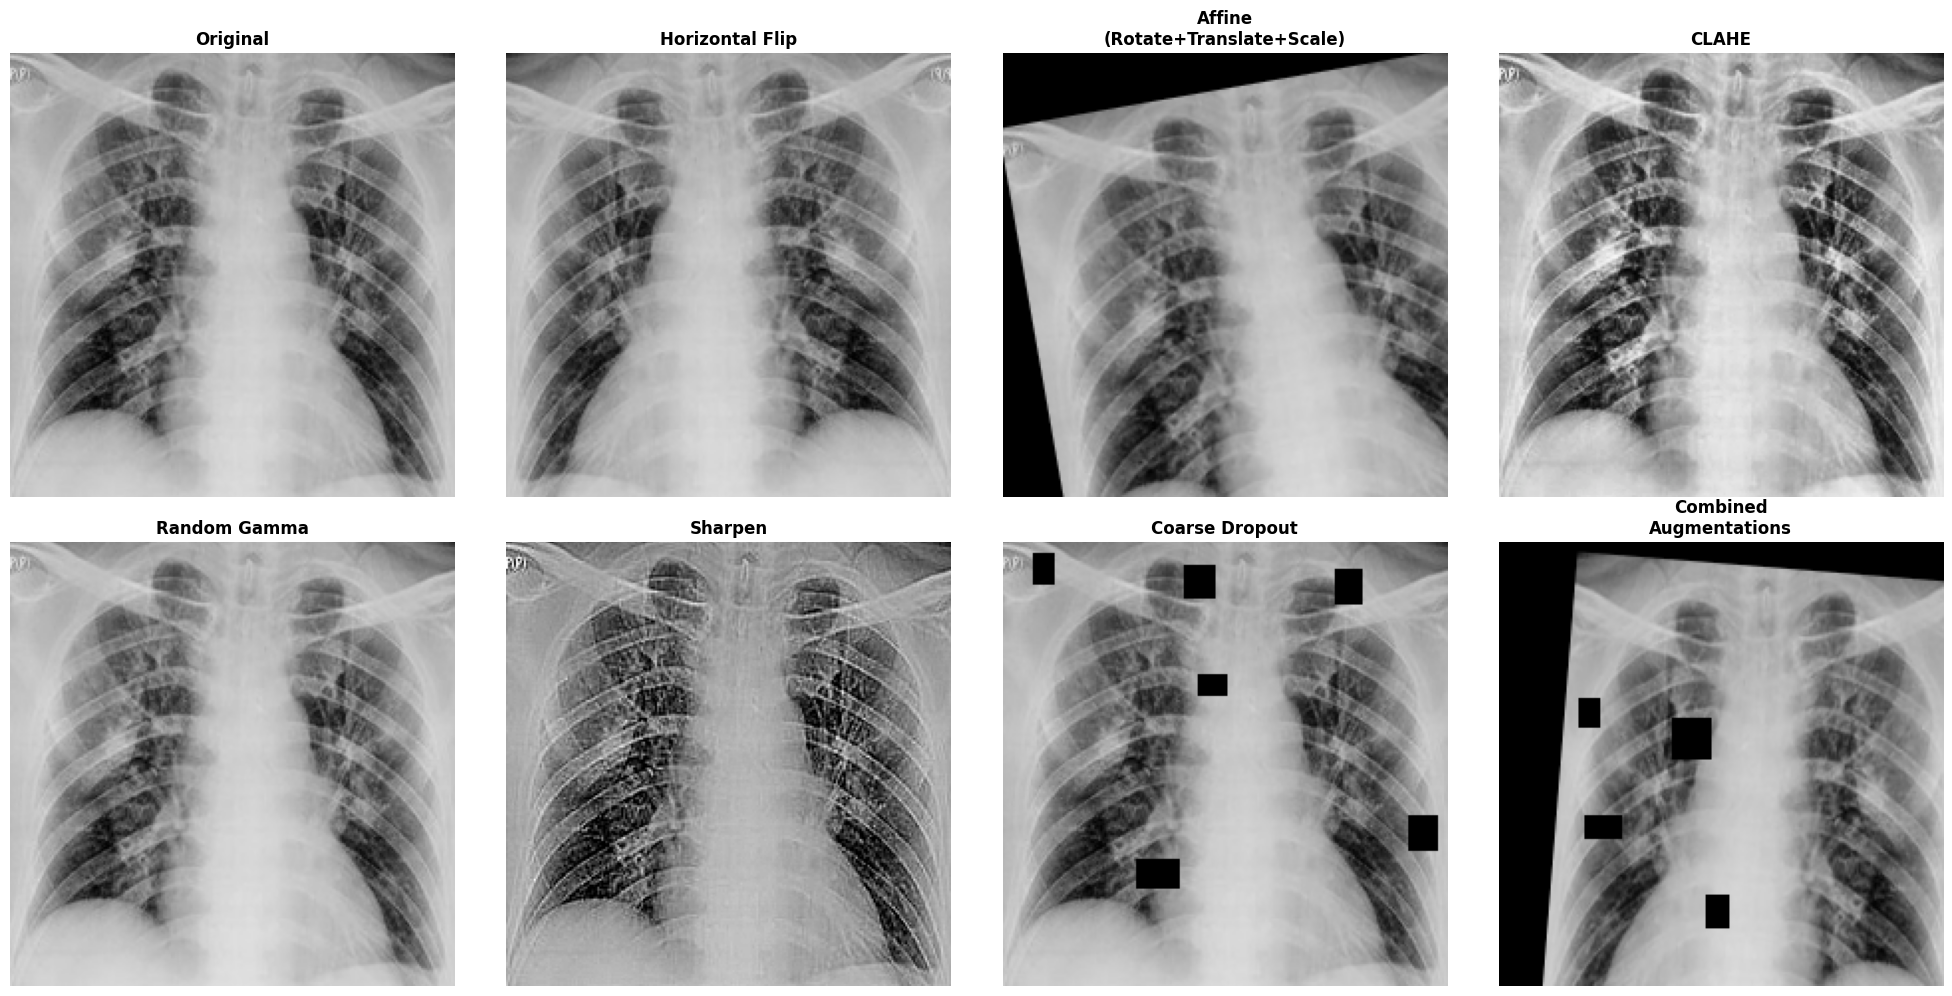

In [24]:
img = cv2.imread("../no_exp/cropped/train_images/4.jpg", cv2.IMREAD_GRAYSCALE)
img_rgb = gray_to_rgb(img)

# 創建各種增強效果的函數
def show_individual_augmentations(image, img_size=224):
    """
    分別展示每種資料增強技術的效果
    """
    import matplotlib.pyplot as plt
    
    # 原始圖片 (只做 resize)
    original_transform = A.Compose([
        A.Resize(img_size, img_size),
    ])
    
    # 1. 水平翻轉
    flip_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=1.0),
    ])
    
    # 2. 仿射變換 (旋轉、平移、縮放)
    affine_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Affine(rotate=10, translate_percent=0.1, scale=1.05, p=1.0),
    ])
    
    # 3. CLAHE
    clahe_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    ])
    
    # 4. Gamma 調整
    gamma_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
    ])
    
    # 5. 銳化
    sharpen_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.Sharpen(alpha=(0.2, 0.3), lightness=(0.5, 1.0), p=1.0),
    ])
    
    # 6. CoarseDropout (遮擋)
    dropout_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.CoarseDropout(
            num_holes_range=(6, 8),
            hole_height_range=(int(img_size * 0.05), int(img_size * 0.1)),
            hole_width_range=(int(img_size * 0.05), int(img_size * 0.1)),
            p=1.0
        ),
    ])
    
    # 7. 組合所有增強
    combined_transform = A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Affine(rotate=(-10, 10), translate_percent=0.1, scale=(0.9, 1.1), p=0.7),
        A.OneOf([
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.7),
            A.RandomGamma(gamma_limit=(80, 120), p=0.7),
            A.Sharpen(alpha=(0.1, 0.3), lightness=(0.5, 1.0), p=0.5),
        ], p=0.8),
        A.CoarseDropout(
            num_holes_range=(4, 8),
            hole_height_range=(int(img_size * 0.05), int(img_size * 0.1)),
            hole_width_range=(int(img_size * 0.05), int(img_size * 0.1)),
            p=0.5
        ),
    ])
    
    # 應用所有變換
    transforms = {
        'Original': original_transform,
        'Horizontal Flip': flip_transform,
        'Affine\n(Rotate+Translate+Scale)': affine_transform,
        'CLAHE': clahe_transform,
        'Random Gamma': gamma_transform,
        'Sharpen': sharpen_transform,
        'Coarse Dropout': dropout_transform,
        'Combined\nAugmentations': combined_transform,
    }
    
    # 創建子圖
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    for idx, (name, transform) in enumerate(transforms.items()):
        augmented = transform(image=image)
        aug_img = augmented['image']
        
        axes[idx].imshow(aug_img, cmap='gray')
        axes[idx].set_title(name, fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# 顯示各種增強效果
show_individual_augmentations(img_rgb, img_size=224)